In [1]:
"""
This script is to extract the topics assigned to each cell

authors: Roy Oelen
"""


'\nThis script is to extract the topics assigned to each cell\n\nauthors: Roy Oelen\n'

In [2]:
import os
import pycisTopic
import pandas as pd
import pickle
from pycisTopic.topic_binarization import binarize_topics
from pycisTopic.topic_qc import compute_topic_metrics, plot_topic_qc, topic_annotation
import matplotlib.pyplot as plt
from pycisTopic.utils import fig2img

In [3]:
# location of the existing cistopic objects
cistopic_objects_loc='/scratch/hb-functionalgenomics/projects/multiome/ongoing/scenicplus_workdir/pycistopic/monocytes_all_cells/cistopic_objects/'
# the object to use
cistopic_object_loc=''.join([cistopic_objects_loc, 'cistopic_obj_20_topics_model.pkl'])
# read the object
with open(cistopic_object_loc, 'rb') as f:
    cistopic_object = pickle.load(f)


/home3/p287578/miniconda3/envs/scenicplus/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-09-16 09:06:25,650	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [4]:
# check which metadata we have
cistopic_object.cell_data.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcode', 'barcode_1',
       'barcode_lane', 'lane', 'batch', 'percent.mt', 'nCount_RNA_mad',
       'nFeature_RNA_mad', 'confined_best_match_sample',
       'confined_second_match_sample', 'confined_best_match_correlation',
       'confined_second_match_correlation', 'confined_condition',
       'unconfined_best_match_sample', 'unconfined_second_match_sample',
       'unconfined_best_match_correlation',
       'unconfined_second_match_correlation', 'unconfined_condition',
       'soup_cluster', 'soup_status', 'soup_singlet_posterior',
       'soup_doublet_posterior', 'soup_log_prob_singleton',
       'soup_log_prob_doublet', 'soup_cluster0', 'soup_cluster1',
       'soup_cluster2', 'soup_cluster3', 'soup_cluster4', 'soup_cluster5',
       'soup_cluster6', 'soup_cluster7', 'sample_final', 'final_condition',
       'predicted.mo_10x_cell_type', 'predicted.mo_10x_cell_type.score',
       'predicted.mo_10x_cell_type.lowerres', 'nCount_S

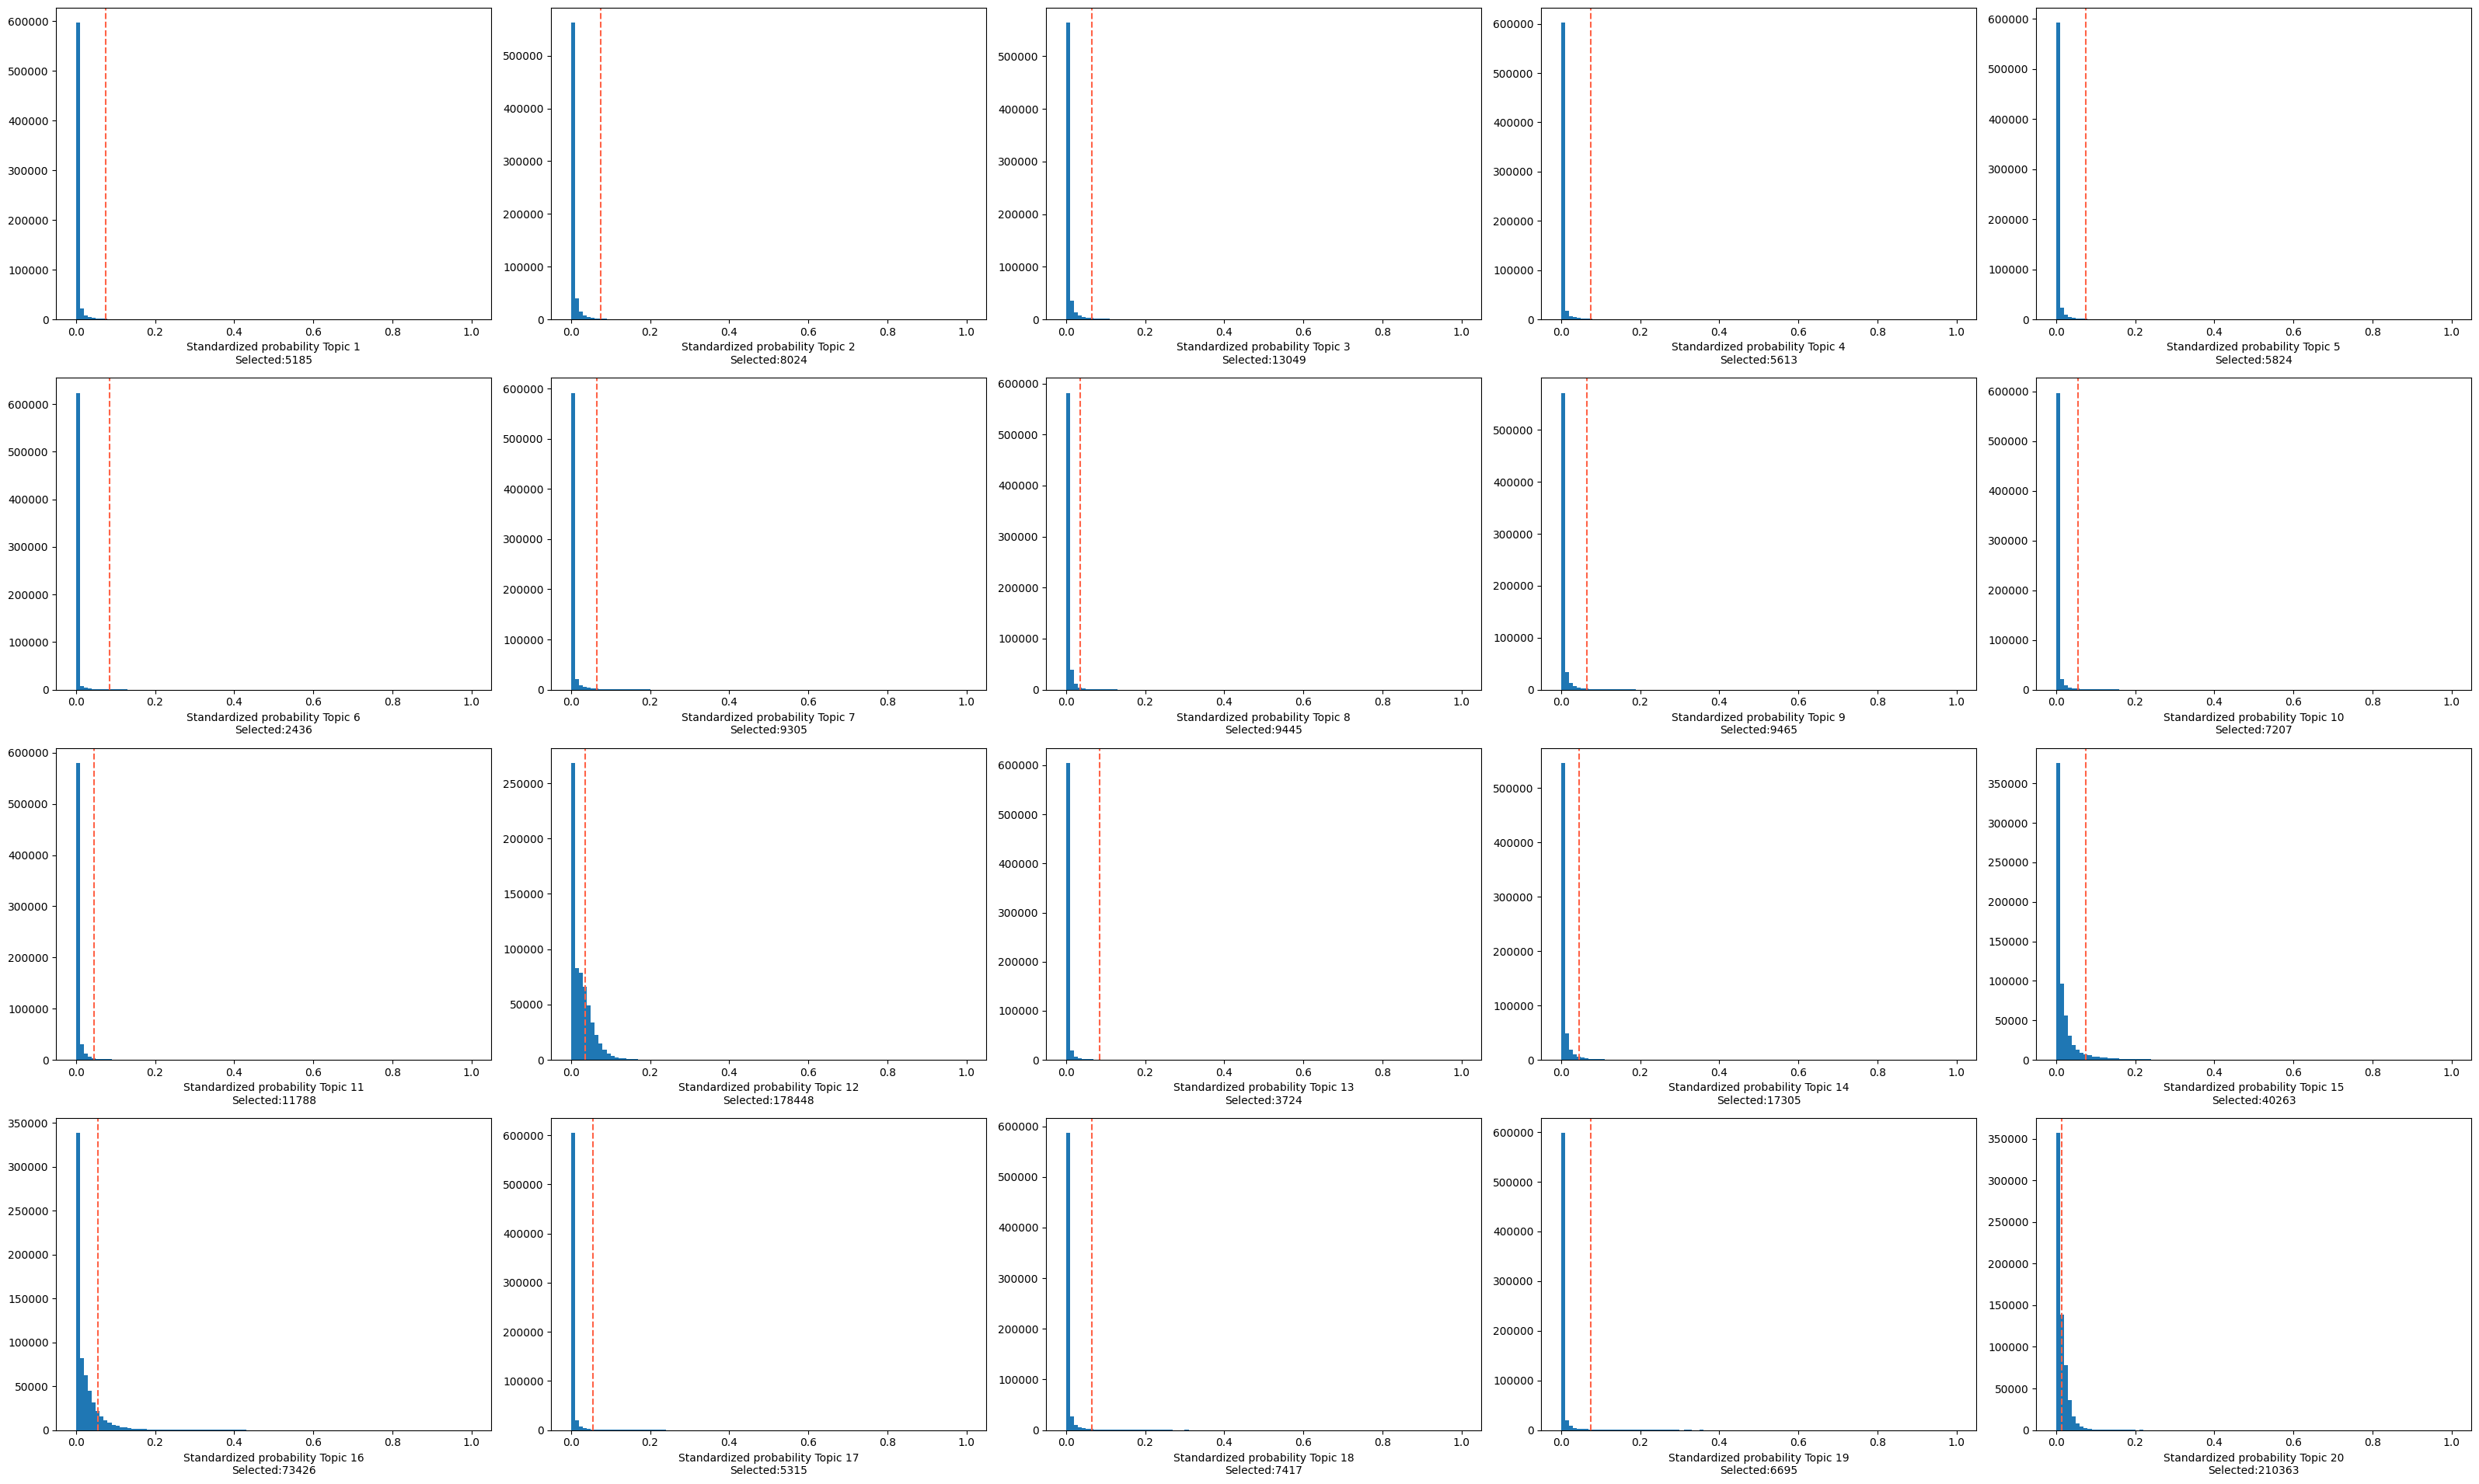

In [5]:
# add regions to topics
region_bin_topics_otsu = binarize_topics(
    cistopic_object, method='otsu',
    plot=True, num_columns=5
)

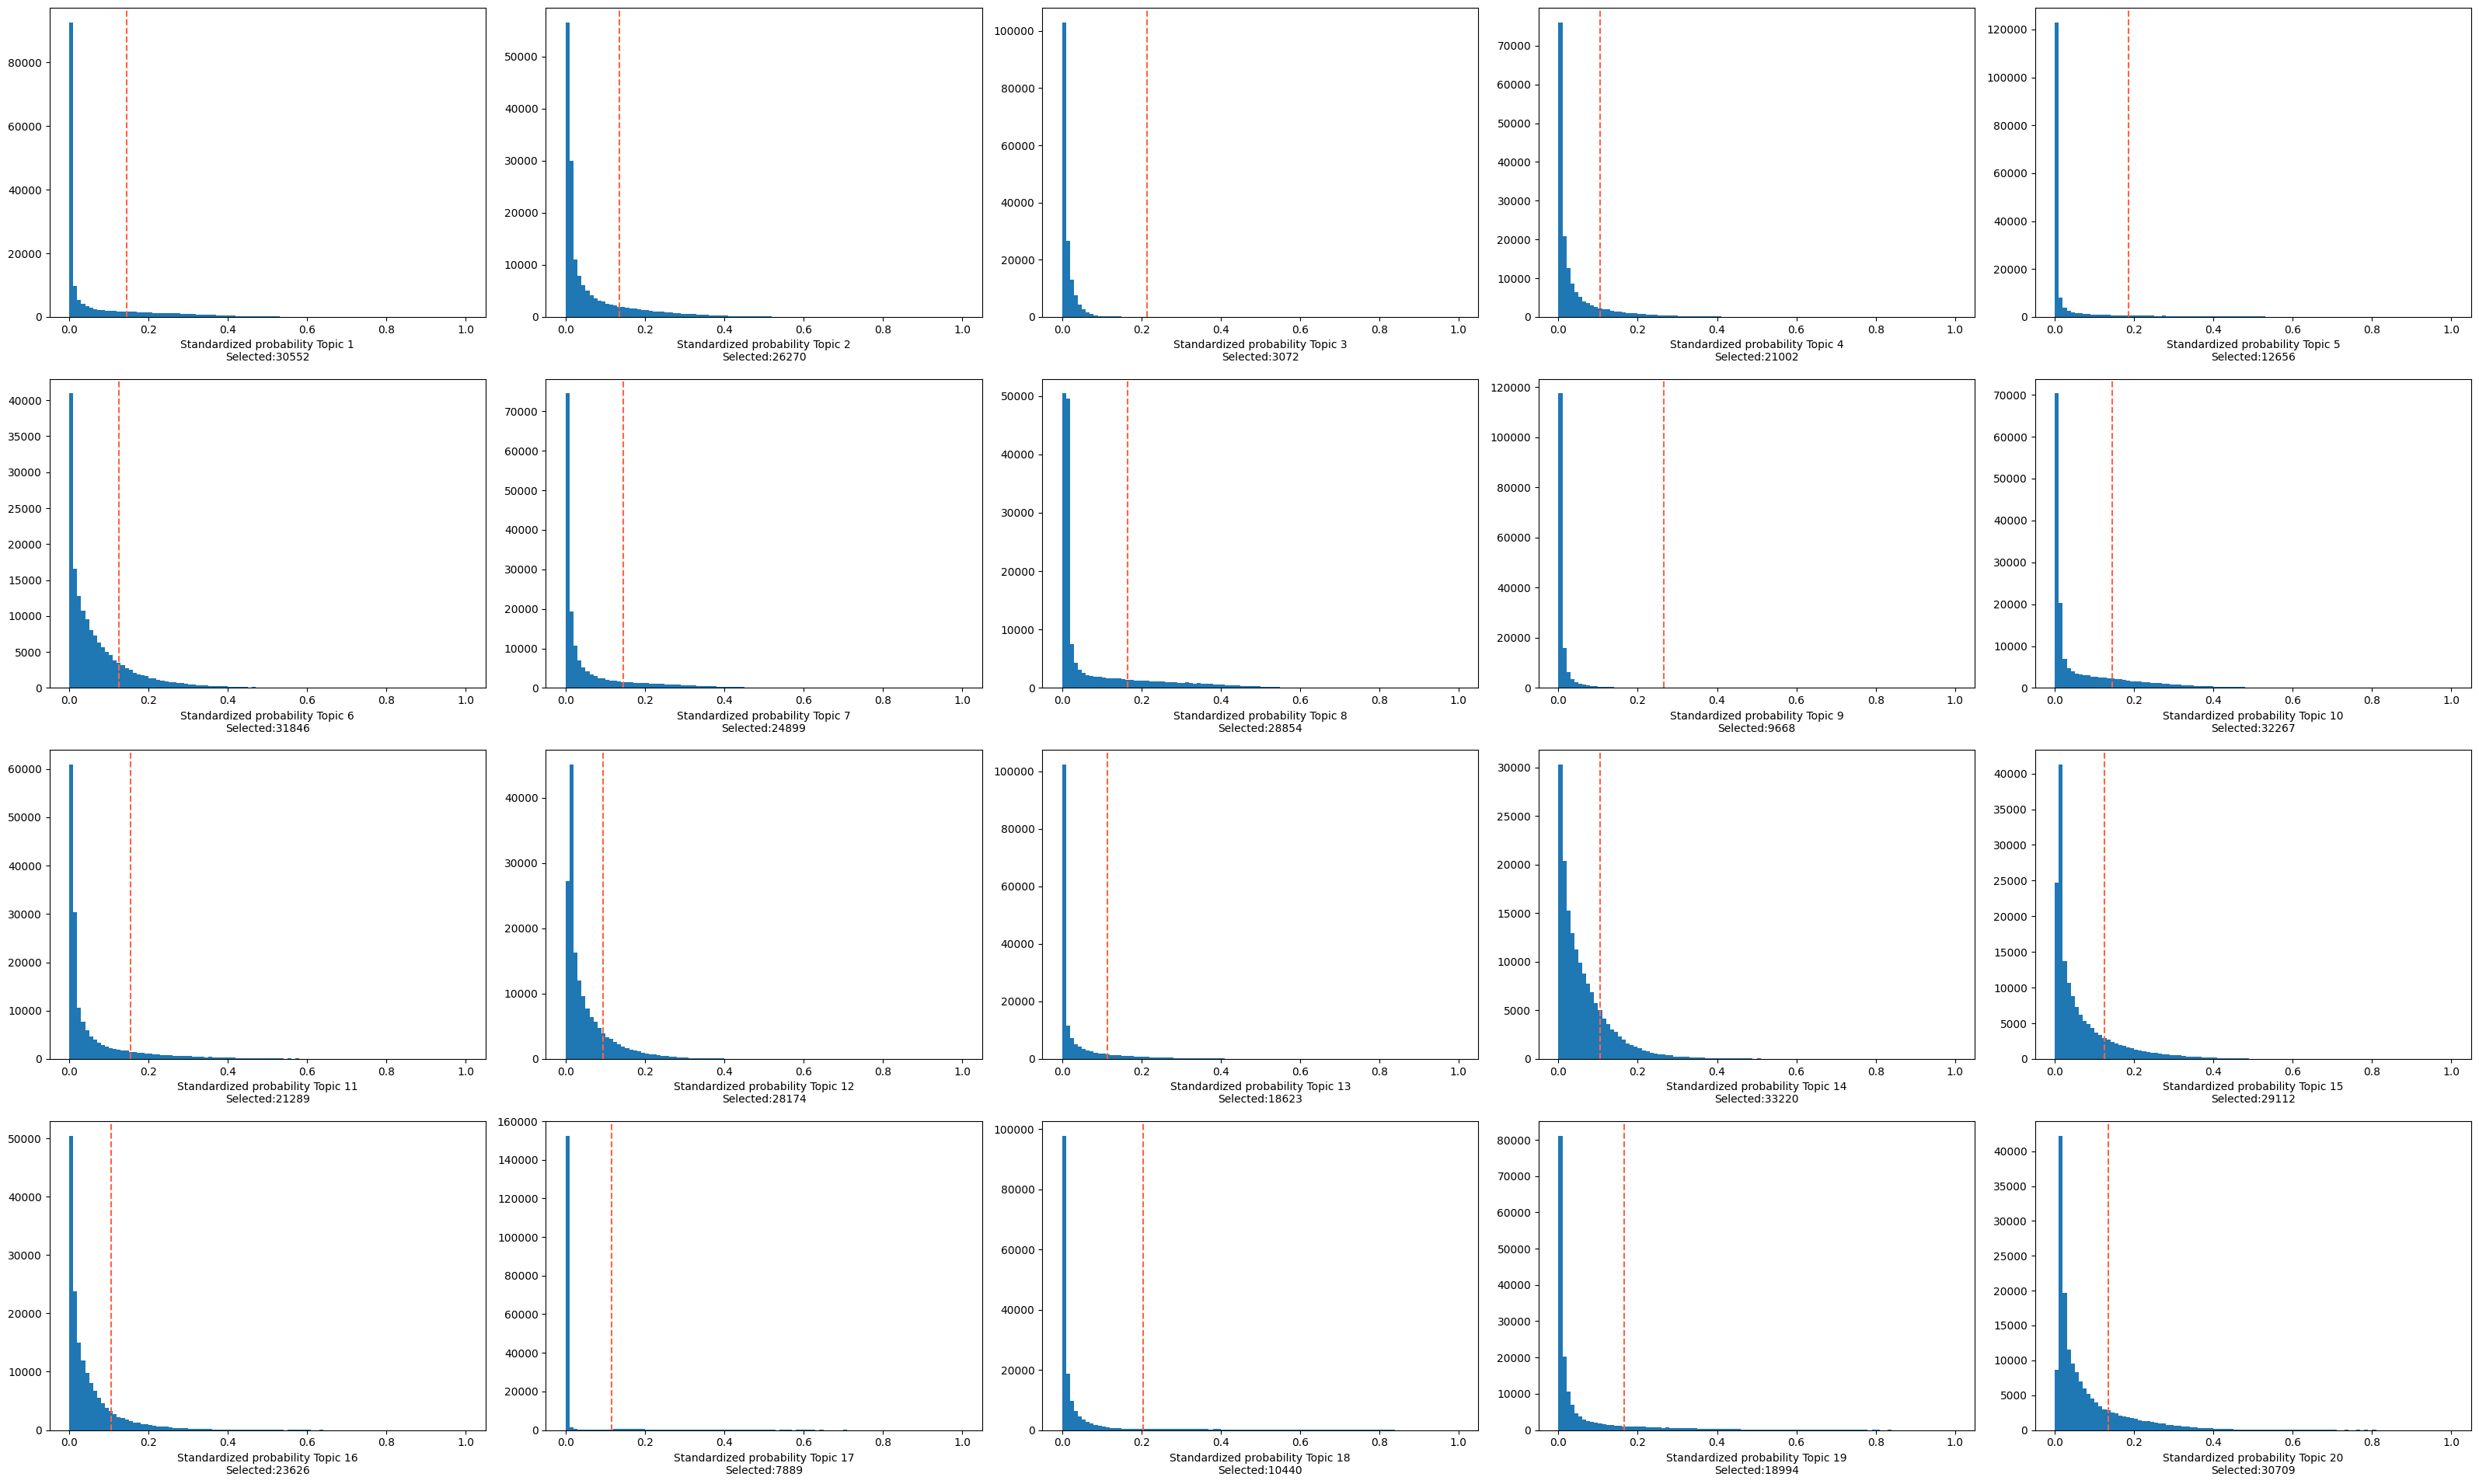

In [6]:
# add cells to topics
binarized_cell_topic = binarize_topics(
    cistopic_object,
    target='cell',
    method='otsu',
    plot=True,
    num_columns=5, nbins=100)

In [7]:
# calculate the QC metrics, we need this to doublet-check if the proportion cells per topic, is concordant with the in_topic dataframe I make later
topic_qc_metrics = compute_topic_metrics(cistopic_object)

In [8]:
# create a new dataframe that will hold info on whether or not the 
in_topic = pd.DataFrame(data={'barcode_lane' : cistopic_object.cell_data['barcode_lane']})
# go through the 20 topics
for i in range(1, 21, 1):
    # get the topic
    topic = ''.join(['Topic', str(i)])
    # set for that topic, whether or not the barcodes were for that topic
    in_topic[topic] = in_topic['barcode_lane'].isin(binarized_cell_topic[topic].index.to_list()).to_list()

In [9]:
# check if we save the topic membership correctly
in_topic

,barcode_lane,Topic1,Topic2,Topic3,Topic4,Topic5,Topic6,Topic7,Topic8,Topic9,...,Topic11,Topic12,Topic13,Topic14,Topic15,Topic16,Topic17,Topic18,Topic19,Topic20
barcode_lane,,,,,,,,,,,,,,,,,,,,,
CTATAACCATAGCTGC_230105_lane1,CTATAACCATAGCTGC_230105_lane1,False,False,False,False,False,False,False,True,False,...,False,True,False,True,False,True,False,False,False,False
AATCAGGAGCTTACTT_230105_lane1,AATCAGGAGCTTACTT_230105_lane1,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
TTACGTTTCAATTGGC_230105_lane1,TTACGTTTCAATTGGC_230105_lane1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
ACTCACTGTCCTAAGA_230105_lane1,ACTCACTGTCCTAAGA_230105_lane1,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
ACAGGAATCGGCTATG_230105_lane1,ACAGGAATCGGCTATG_230105_lane1,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTCTAGCTCCCTGGTT_230316_lane7,CTCTAGCTCCCTGGTT_230316_lane7,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
AAGCGGGTCATAAGCC_230316_lane7,AAGCGGGTCATAAGCC_230316_lane7,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
TCACGGATCATGAGCT_230316_lane7,TCACGGATCATGAGCT_230316_lane7,False,False,False,True,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False


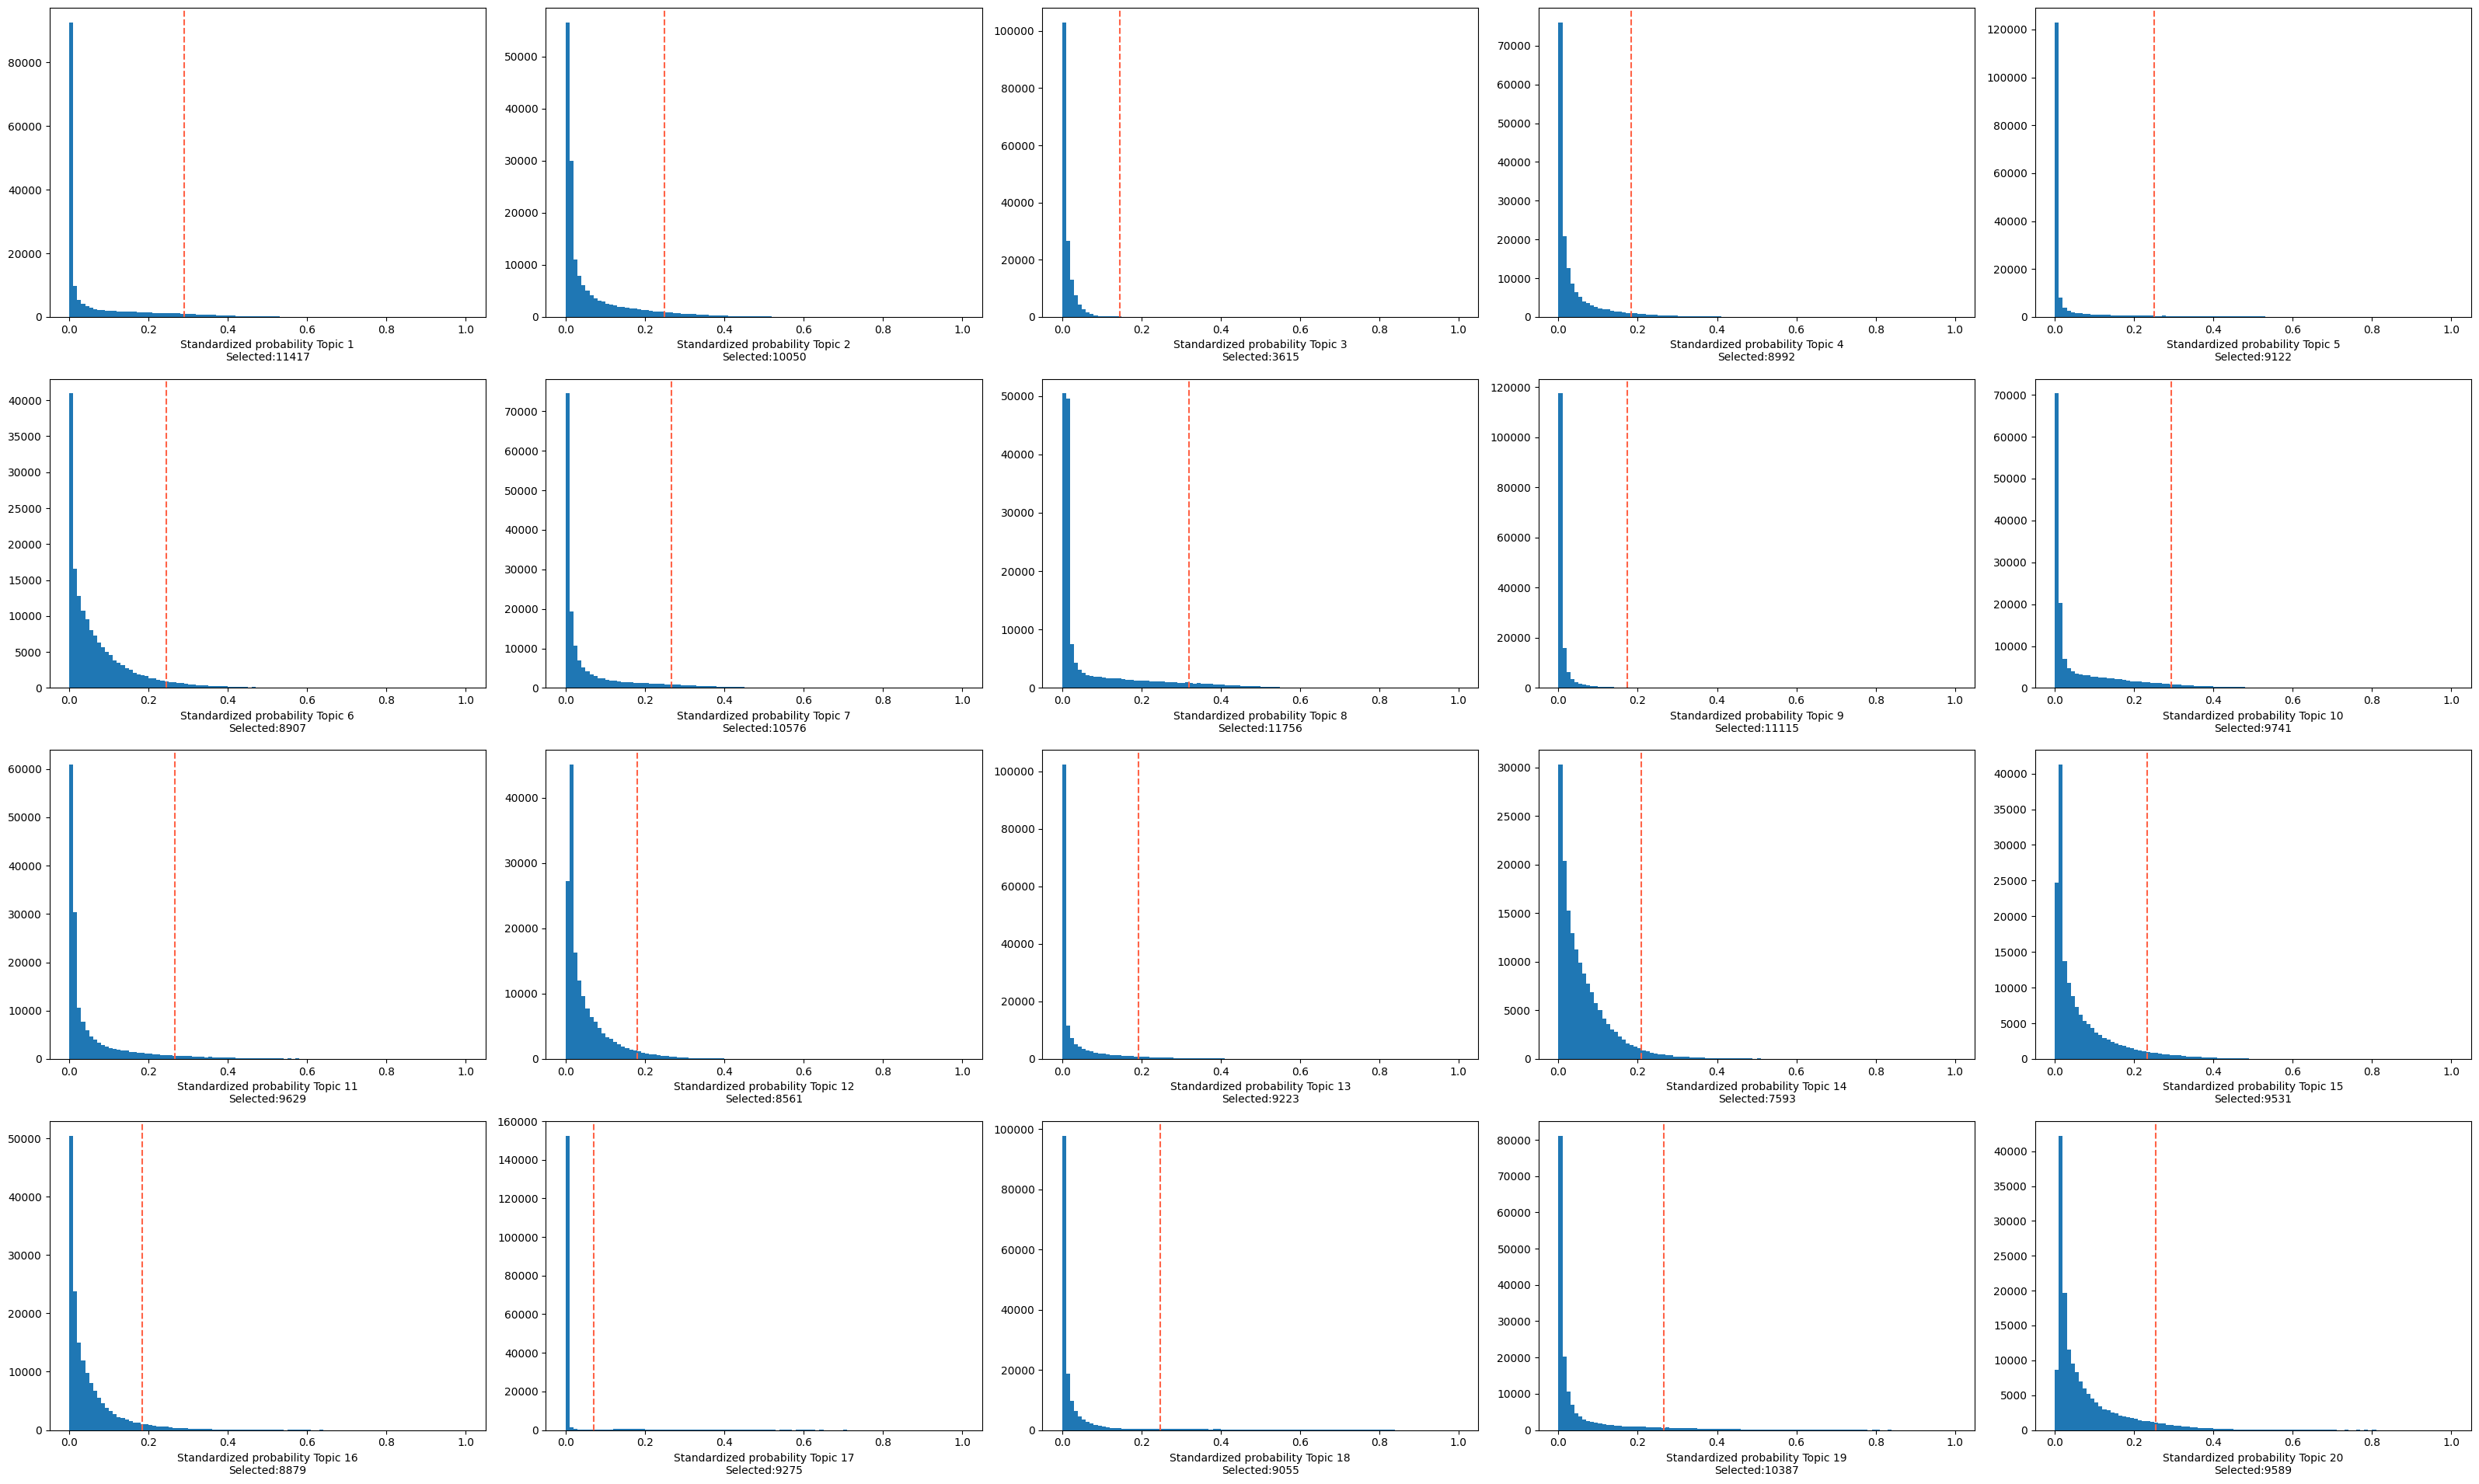

In [10]:
# add cells to topics
binarized_cell_topic_aucell = binarize_topics(
    cistopic_object,
    target='cell',
    method='aucell',
    plot=True,
    num_columns=5, nbins=100)

In [11]:
# create a new dataframe that will hold info on whether or not the 
in_topic_aucell = pd.DataFrame(data={'barcode_lane' : cistopic_object.cell_data['barcode_lane']})
# go through the 20 topics
for i in range(1, 21, 1):
    # get the topic
    topic = ''.join(['Topic', str(i)])
    # set for that topic, whether or not the barcodes were for that topic
    in_topic_aucell[topic] = in_topic_aucell['barcode_lane'].isin(binarized_cell_topic_aucell[topic].index.to_list()).to_list()

In [12]:
# save result
in_topic_otsu_loc = ''.join(['/scratch/hb-functionalgenomics/projects/multiome/ongoing/differential_accessibility/topic_annotations/', 'mo_topic_20_otsu.tsv'])
in_topic_aucell_loc = ''.join(['/scratch/hb-functionalgenomics/projects/multiome/ongoing/differential_accessibility/topic_annotations/', 'mo_topic_20_aucell.tsv'])
in_topic.to_csv(in_topic_otsu_loc, sep = '\t')
in_topic_aucell.to_csv(in_topic_aucell_loc, sep = '\t')